<a href="https://colab.research.google.com/github/Rached-Miri/Rached-/blob/main/Rached_modifier01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a5276 0%, #2e86c1 100%); padding: 36px 40px; border-radius: 10px; color: white; margin-bottom: 20px;">
  <h1 style="color: white; margin: 0 0 8px 0; font-size: 2em;">PINNs for Mechanical Engineers | CFD Series</h1>
  <h2 style="color: #aed6f1; margin: 0 0 12px 0; font-weight: normal; font-size: 1.3em;">Worksheet 5 — 2D Steady Navier-Stokes (Laminar)</h2>
  <p style="color: #85c1e9; margin: 0; font-size: 1em;">Pure PINN &nbsp;·&nbsp; Nonlinear Convection &nbsp;·&nbsp; Re=10 Lid-Driven Cavity &nbsp;·&nbsp; PyTorch</p>
</div>

<div style="background: #fff8dc; border: 1.5px solid #d2aa32; border-radius: 8px; padding: 20px 24px; margin-bottom: 20px;">
  <h3 style="color: #d25a0a; margin: 0 0 12px 0;">📋 How to use this notebook</h3>
  <p>This notebook builds directly on WS4 (Stokes). The only change to the physics is the addition of the <strong>nonlinear convection term</strong> in the momentum equations. Everything else — network structure, BC enforcement, pressure reference — is identical.</p>
  <ol style="line-height: 2;">
    <li>Read Section 1 carefully — understand what changes from Stokes to Navier-Stokes.</li>
    <li>Answer the conceptual questions.</li>
    <li>Fill in the blanks — only the residual expressions change from WS4.</li>
    <li>Run each cell in order.</li>
  </ol>
  <p style="margin:0;">Cells marked <strong>[READ ONLY — just run this cell]</strong> do not need to be modified.</p>
</div>

### Learning Objectives

- Add the **nonlinear convection term** to the Stokes momentum residuals
- Understand why Re=10 produces a qualitatively different flow to Stokes
- Compare PINN results to the well-known Ghia et al. (1982) benchmark data
- Appreciate the increased training difficulty from nonlinearity


---
## Section 1 — The Physical Problem

### 2D Steady Incompressible Navier-Stokes

Adding inertia to the Stokes equations gives the full incompressible Navier-Stokes and Energie Equation:

$$\boxed{\rho\left(u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y}\right) = -\frac{\partial p}{\partial x} + \mu\,\nabla^2 u}$$

$$\boxed{\rho\left(u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y}\right) = -\frac{\partial p}{\partial y} + \mu\,\nabla^2 v -g * beta * (T - T_ref)}$$

$$\boxed{\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0}$$

$$\boxed {u \frac{\partial TT}{\partial x}+{v \frac{\partial TT}{\partial y}=\alpha \left(\frac{\partial^2 TT}{\partial x^2}+\frac{\partial^2 TT}{\partial y^2}\right)}}$$

The **only difference from WS4** is the left-hand side — the convection terms $\rho(u\,\partial u/\partial x + v\,\partial u/\partial y)$ and $\rho(u\,\partial v/\partial x + v\,\partial v/\partial y)$.

We solve the same **lid-driven cavity** at **Re = 10** ($\rho=1.00052$, $\mu=0.01002$, $U_{lid}=1$, $L=1$). The flow is still laminar but inertia causes the primary vortex to shift from the centre towards the top-right.

| Parameter | Symbol | Value |
|---|---|---|
| Density | $\rho$ | 1.00052 kg/m³ |
| Viscosity | $\mu$ | 0.01002 Pa·s |
| Lid velocity | $U_{lid}$ | 0.0001 m/s |
g = 9.81
beta = 2.07e-4
T_ref = 20.0
| Reynolds number | Re | $\rho U L/\mu = 10$ |

---
## Section 1 — The Physical Problem

### 2D Steady Incompressible Navier-Stokes and Energie Eq

Adding inertia to the Stokes equations gives the full incompressible Navier-Stokes and energie equation:

$$\boxed{\rho\left(u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y}\right) = -\frac{\partial p}{\partial x} + \mu\,\nabla^2 u}$$

$$\boxed{\rho\left(u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y}\right) = -\frac{\partial p}{\partial y} + \mu\,\nabla^2 v -g * beta * (T - T_ref)}$$

$$\boxed{\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0}$$
$$\boxed {u \frac{\partial TT}{\partial x}+{v \frac{\partial TT}{\partial y}=\alpha \left(\frac{\partial^2 TT}{\partial x^2}+\frac{\partial^2 TT}{\partial y^2}\right)}}$$

The **only difference from WS4** is the left-hand side — the convection terms $\rho(u\,\partial u/\partial x + v\,\partial u/\partial y)$ and $\rho(u\,\partial v/\partial x + v\,\partial v/\partial y)$.

We solve the same **lid-driven cavity** at **Re = 10** ($\rho=1.00052$, $\mu=0.01002$, $U_{lid}=0.0001$, $L=1$). The flow is still laminar but inertia causes the primary vortex to shift from the centre towards the top-right.

| Parameter | Symbol | Value |
|---|---|---|
| Density | $\rho$ | 1.00052 kg/m³ |
| Viscosity | $\mu$ | 0.01002 Pa·s |
| Lid velocity | $U_{lid}$ | 1 m/s |
g = 9.81
beta = 2.07e-4
T_ref = 20.0
| Reynolds number | Re | $\rho U L/\mu = 10$ |

In [2]:

rho   = 1000.52
  # kg/m3
mu    = 0.001002
  # Pa.s
k     = 0.597
  # W/(m.K)
cp    = 4181.8
  # J/(kg.K)
beta  = 2.07e-4
  # 1/K
g     = 9.81
  # m/s2
L     = 1.0
# m
alpha = k / (rho * cp)
nu  = (mu / rho)
print("alpha =", alpha)
print("nu    =", nu)
Ra = 1.0e4

DeltaT = Ra * nu * alpha / (g * beta * L**3)

print("Ra      =", Ra)
print("DeltaT  =", DeltaT)

Ra = 1.0e4
Pr = 7.03

# Domaine adimensionnel
L = 1.0

# Conditions thermiques
T_hot  = 1.0
T_cold = 0.0

alpha = 1.4268729287505395e-07
nu    = 1.0014792307999842e-06
Ra      = 10000.0
DeltaT  = 7.037005535780855e-07


✏️ Q1 — Navier-Stokes vs Stokes

**(a)** Write down the x-momentum residual for NS. Which term is new compared to WS4?

**(b)** The convection term $u\,\partial u/\partial x$ is nonlinear — it multiplies the network output by its own derivative. Does this cause any problem for the autograd computation? Explain.

**(c)** At Re=10, the primary vortex centre shifts towards the geometric centre compared to Stokes flow. What physical mechanism causes this shift?

**Your answer (a):** *(double-click to edit)*

**Your answer (b):** *(double-click to edit)*

**Your answer (c):** *(double-click to edit)*

---
## Section 2 — PINN Formulation

### Three Residuals (NS) and Energie eq

$$r_1 = \rho\left(\hat{u}\frac{\partial\hat{u}}{\partial x} + \hat{v}\frac{\partial\hat{u}}{\partial y}\right) + \frac{\partial\hat{p}}{\partial x} - \mu\left(\frac{\partial^2\hat{u}}{\partial x^2} + \frac{\partial^2\hat{u}}{\partial y^2}\right)$$

$$r_2 = \rho\left(\hat{u}\frac{\partial\hat{v}}{\partial x} + \hat{v}\frac{\partial\hat{v}}{\partial y}\right) + \frac{\partial\hat{p}}{\partial y} - \mu\left(\frac{\partial^2\hat{v}}{\partial x^2} + \frac{\partial^2\hat{v}}{\partial y^2}-g * beta * (T - T_ref)\right)$$

$$r_3 = \frac{\partial\hat{u}}{\partial x} + \frac{\partial\hat{v}}{\partial y}$$

$$r_T = \hat{u}\frac{\partial\hat{T}}{\partial x} + \hat{v}\frac{\partial\hat{T}}{\partial y} - \alpha\left(\frac{\partial^2\hat{T}}{\partial x^2} + \frac{\partial^2\hat{T}}{\partial y^2}\right)$$

<div style="background: #fef9e7; border: 1.5px solid #f39c12; border-radius: 8px; padding: 16px 20px; margin: 16px 0;">
<strong>⚠️ Training note:</strong> Navier-Stokes PINNs are more sensitive than scalar transport problems. We use a <strong>curriculum strategy</strong>: train first with a higher continuity loss weight to establish an incompressible velocity field, then relax. If your loss stagnates, try re-running with a different random seed or adjusting <code>lambda_bc</code>.
</div>

✏️ Q2 — The Nonlinear Term

**(a)** The term $\hat{u}\,\partial\hat{u}/\partial x$ multiplies the network output $\hat{u}$ (a tensor) by its spatial derivative (also a tensor). Both are available after the autograd calls. Write this in PyTorch syntax.

**(b)** At Re=10 the nonlinear term is $\rho(u\,u_x + v\,u_y) \sim O(1)$ while the viscous term is $\mu\nabla^2 u \sim O(\mu/L^2) = O(0.01)$. Which dominates? How does this affect loss balance?

**(c)** Why do we train for 30,000 epochs here vs 20,000 for Stokes?

**Your answer (a):** *(double-click to edit)*

**Your answer (b):** *(double-click to edit)*

**Your answer (c):** *(double-click to edit)*

---
## Section 3 — Coding Implementation

### Step 1 — Imports

🟢 **READ ONLY**

In [3]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Step 2 — Parameters

🟢 **READ ONLY**

In [4]:

# Propriétés physiques de l'eau
rho = 1000.52
# masse volumique [kg/m^3]
mu  = 0.001002
# viscosité dynamique [Pa.s]
k   = 0.597
# conductivité thermique [W/(m.K)]
c_p = 4181.8
# capacité thermique [J/(kg.K)]



# Propriétés dérivées
nu    = mu / rho
# viscosité cinématique [m^2/s]
alpha = k / (rho * c_p)
# diffusivité thermique [m^2/s]

# Paramètres de convection naturelle
g    = 9.81
# gravité [m/s^2]
beta = 2.07e-4
# coefficient de dilatation thermique [1/K]
L    = 1.0
# longueur de la cavité [m]
# Nombre de Prandtl
Pr = nu / alpha
# Nombre de Rayleigh souhaité
Ra = 1.0e4
print(f"rho   = {rho:.2f} kg/m^3")
print(f"mu    = {mu:.6f} Pa.s")
print(f"k     = {k:.3f} W/(m.K)")
print(f"cp    = {c_p:.1f} J/(kg.K)")
print(f"nu    = {nu:.6e} m^2/s")
print(f"alpha = {alpha:.6e} m^2/s")
print(f"Pr    = {Pr:.4f}")
print(f"Ra    = {Ra:.2e}")

rho   = 1000.52 kg/m^3
mu    = 0.001002 Pa.s
k     = 0.597 W/(m.K)
cp    = 4181.8 J/(kg.K)
nu    = 1.001479e-06 m^2/s
alpha = 1.426873e-07 m^2/s
Pr    = 7.0187
Ra    = 1.00e+04


### Step 3 — Network

🟢 **READ ONLY**

Identical to WS4 — three outputs $(u, v, p,TT)$, four hidden layers.

In [5]:
class FullyConnectedNN(nn.Module):

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()

        activation = nn.Tanh

        # Première couche
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )

        # Couches cachées
        self.fch = nn.Sequential(
            *[
                nn.Sequential(
                    nn.Linear(N_HIDDEN, N_HIDDEN),
                    activation()
                )
                for _ in range(N_LAYERS - 1)
            ]
        )

        # Couche de sortie
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    # IMPORTANT : forward doit être à l'intérieur de la classe
    def forward(self, x):

        x = self.fcs(x)
        x = self.fch(x)

        return self.fce(x)


# Reproductibilité
torch.manual_seed(123)

# Création du PINN
pinn = FullyConnectedNN(
    N_INPUT=2,
    N_OUTPUT=4,
    N_HIDDEN=64,
    N_LAYERS=4
).to(device)

print(
    f"Network: {sum(p.numel() for p in pinn.parameters())} parameters"
)

Network: 12932 parameters


In [6]:
N_bc=100; N_phys=5000

x_top = torch.rand(N_bc, 1, device=device); y_top = torch.ones(N_bc, 1, device=device)
x_bot=torch.rand(N_bc,1,device=device); y_bot=torch.zeros(N_bc,1,device=device)
# Paroi gauche : chaude T = 1
T_lft = torch.ones(N_bc, 1, device=device)

# Paroi droite : froide T = 0
T_rgt = torch.zeros(N_bc, 1, device=device)

T_bot=torch.ones(N_bc,1,device=device)
x_lft=torch.zeros(N_bc,1,device=device); y_lft=torch.rand(N_bc,1,device=device)
x_rgt=torch.ones(N_bc,1,device=device);  y_rgt=torch.rand(N_bc,1,device=device)
x_pref=torch.zeros(1,1,device=device);   y_pref=torch.zeros(1,1,device=device)

x_phys=torch.rand(N_phys,1,device=device,requires_grad=True)
y_phys=torch.rand(N_phys,1,device=device,requires_grad=True)

lambda_bc=10.0; lambda_phys=1.0; epochs=30000
optimiser=torch.optim.Adam(pinn.parameters(), lr=1e-3)
scheduler=torch.optim.lr_scheduler.StepLR(optimiser, step_size=10000, gamma=0.5)
loss_history=[]
print(f"Training for {epochs} epochs...")

Training for 30000 epochs...


### Step 5 — Training Loop

🟠 **YOUR TURN — Fill in the blanks**

**Blank A** — x-momentum NS residual.

Add the convection term to the WS4 Stokes residual:
➡️ `rho*(u*du_dx + v*du_dy) + dp_dx - mu*(d2u_dx2 + d2u_dy2)`

**Blank B** — y-momentum NS residual:
➡️ `rho*(u*dv_dx + v*dv_dy) + dp_dy - mu*(d2v_dx2 + d2v_dy2)`

In [7]:

# ENTRAINEMENT DU PINN - CONVECTION NATURELLE
# ============================================================
# ENTRAINEMENT DU PINN - CONVECTION NATURELLE
# Cavité carrée - Ra = 1e4
# Sorties : u, v, p, T
# ============================================================

# Paramètres adimensionnels
Ra = 1.0e4
Pr = 7.03

# Coefficients diffusifs adimensionnels
nu_star = (Pr / Ra) ** 0.5
alpha_star = 1.0 / (Ra * Pr) ** 0.5

print(f"Ra = {Ra:.1e}")
print(f"Pr = {Pr:.3f}")
print(f"nu_star = {nu_star:.6e}")
print(f"alpha_star = {alpha_star:.6e}")


# ============================================================
# FONCTION POUR LES CONDITIONS AUX LIMITES
# ============================================================

def wall_loss(x, y, u_target=0.0, v_target=0.0, T_target=None):
    xy = torch.cat((x, y), dim=1)
    out = pinn(xy)

    u_pred = out[:, 0:1]
    v_pred = out[:, 1:2]
    T_pred = out[:, 3:4]
    loss_u = torch.mean((u_pred - u_target)**2)
    loss_v = torch.mean((v_pred - v_target)**2)

    if T_target is not None:
        loss_T = torch.mean((T_pred - T_target)**2)
    else:
        loss_T = torch.tensor(0.0, device=x.device)

    return loss_u + loss_v + loss_T

#######
import torch
import torch.nn as nn
import torch.optim as optim
# ============================================================
# TEMPERATURES DES PAROIS
# ============================================================

# Paroi gauche : chaude
T_lft = torch.ones(N_bc, 1, device=device)

# Paroi droite : froide
T_rgt = torch.zeros(N_bc, 1, device=device)


# ============================================================
# ENTRAINEMENT
# ============================================================

for i in tqdm(
    range(epochs + 1),
    desc="Training Natural Convection (Ra=1e4)"
):

    optimiser.zero_grad()


    # ========================================================
    # 1. CONDITIONS AUX LIMITES
    # ========================================================

    # --------------------------------------------------------
    # Paroi gauche : u = 0, v = 0, T = 1
    # --------------------------------------------------------

    loss_left = wall_loss(
    x_lft,
    y_lft,
    u_target=0.0,
    v_target=0.0,
    T_target=T_lft)


    # --------------------------------------------------------
    # Paroi droite : u = 0, v = 0, T = 0
    # --------------------------------------------------------

    loss_right = wall_loss(
        x_rgt,
        y_rgt,
        u_target=0.0,
        v_target=0.0,
        T_target=T_rgt
    )


    # --------------------------------------------------------
    # Paroi inférieure : u = 0, v = 0
    # --------------------------------------------------------

    loss_bottom = wall_loss(
        x_bot,
        y_bot,
        u_target=0.0,
        v_target=0.0
    )


    # --------------------------------------------------------
    # Paroi supérieure : u = 0, v = 0
    # --------------------------------------------------------

    loss_top = wall_loss(
        x_top,
        y_top,
        u_target=0.0,
        v_target=0.0
    )


    # ========================================================
    # 2. CONDITIONS ADIABATIQUES
    #    dT/dy = 0 en haut et en bas
    # ========================================================

    # --------------------------------------------------------
    # Paroi inférieure
    # --------------------------------------------------------

    x_bot_grad = x_bot.clone().detach().requires_grad_(True)
    y_bot_grad = y_bot.clone().detach().requires_grad_(True)

    out_bot = pinn(
        torch.cat([x_bot_grad, y_bot_grad], dim=1)
    )

    T_bot_pred = out_bot[:, 3:4]

    dTdy_bot = torch.autograd.grad(
        T_bot_pred,
        y_bot_grad,
        torch.ones_like(T_bot_pred),
        create_graph=True
    )[0]

    loss_adiabatic_bottom = torch.mean(
        dTdy_bot ** 2
    )


    # --------------------------------------------------------
    # Paroi supérieure
    # --------------------------------------------------------

    x_top_grad = x_top.clone().detach().requires_grad_(True)
    y_top_grad = y_top.clone().detach().requires_grad_(True)

    out_top = pinn(
        torch.cat([x_top_grad, y_top_grad], dim=1)
    )

    T_top_pred = out_top[:, 3:4]

    dTdy_top = torch.autograd.grad(
        T_top_pred,
        y_top_grad,
        torch.ones_like(T_top_pred),
        create_graph=True
    )[0]

    loss_adiabatic_top = torch.mean(
        dTdy_top ** 2
    )


    # ========================================================
    # 3. PRESSION : p(0,0) = 0
    # ========================================================

    out_pref = pinn(
        torch.cat([x_pref, y_pref], dim=1)
    )

    loss_pressure = torch.mean(
        out_pref[:, 2:3] ** 2
    )


    # ========================================================
    # 4. LOSS DES CONDITIONS AUX LIMITES
    # ========================================================

    loss_bc = (
        loss_left
        + loss_right
        + loss_bottom
        + loss_top
        + loss_adiabatic_bottom
        + loss_adiabatic_top
        + loss_pressure
    )


    # ========================================================
    # 5. POINTS INTERNES
    # ========================================================

    xy = torch.cat(
        [x_phys, y_phys],
        dim=1
    )

    out = pinn(xy)

    u = out[:, 0:1]
    v = out[:, 1:2]
    p = out[:, 2:3]
    T = out[:, 3:4]


    # ========================================================
    # 6. PREMIERES DERIVEES
    # ========================================================

    du_dx = torch.autograd.grad(
        u,
        x_phys,
        torch.ones_like(u),
        create_graph=True
    )[0]

    du_dy = torch.autograd.grad(
        u,
        y_phys,
        torch.ones_like(u),
        create_graph=True
    )[0]

    dv_dx = torch.autograd.grad(
        v,
        x_phys,
        torch.ones_like(v),
        create_graph=True
    )[0]

    dv_dy = torch.autograd.grad(
        v,
        y_phys,
        torch.ones_like(v),
        create_graph=True
    )[0]

    dp_dx = torch.autograd.grad(
        p,
        x_phys,
        torch.ones_like(p),
        create_graph=True
    )[0]

    dp_dy = torch.autograd.grad(
        p,
        y_phys,
        torch.ones_like(p),
        create_graph=True
    )[0]

    # Température
    dT_dx = torch.autograd.grad(
        T,
        x_phys,
        torch.ones_like(T),
        create_graph=True
    )[0]

    dT_dy = torch.autograd.grad(
        T,
        y_phys,
        torch.ones_like(T),
        create_graph=True
    )[0]


    # ========================================================
    # 7. SECONDES DERIVEES
    # ========================================================

    d2u_dx2 = torch.autograd.grad(
        du_dx,
        x_phys,
        torch.ones_like(du_dx),
        create_graph=True
    )[0]

    d2u_dy2 = torch.autograd.grad(
        du_dy,
        y_phys,
        torch.ones_like(du_dy),
        create_graph=True
    )[0]

    d2v_dx2 = torch.autograd.grad(
        dv_dx,
        x_phys,
        torch.ones_like(dv_dx),
        create_graph=True
    )[0]

    d2v_dy2 = torch.autograd.grad(
        dv_dy,
        y_phys,
        torch.ones_like(dv_dy),
        create_graph=True
    )[0]

    d2T_dx2 = torch.autograd.grad(
        dT_dx,
        x_phys,
        torch.ones_like(dT_dx),
        create_graph=True
    )[0]

    d2T_dy2 = torch.autograd.grad(
        dT_dy,
        y_phys,
        torch.ones_like(dT_dy),
        create_graph=True
    )[0]


    # ========================================================
    # 8. EQUATIONS ADIMENSIONNELLES
    # ========================================================

    # --------------------------------------------------------
    # Continuité
    # du/dx + dv/dy = 0
    # --------------------------------------------------------

    r1 = du_dx + dv_dy


    # --------------------------------------------------------
    # Quantité de mouvement suivant x
    # --------------------------------------------------------

    r2 = (
        u * du_dx
        + v * du_dy
        + dp_dx
        - nu_star * (
            d2u_dx2 + d2u_dy2
        )
    )


    # --------------------------------------------------------
    # Quantité de mouvement suivant y
    # --------------------------------------------------------
    # Terme de flottabilité : +T
    # --------------------------------------------------------

    r3 = (
        u * dv_dx
        + v * dv_dy
        + dp_dy
        - nu_star * (
            d2v_dx2 + d2v_dy2
        )
        - T
    )


    # --------------------------------------------------------
    # Equation de l'énergie
    # --------------------------------------------------------

    r4 = (
        u * dT_dx
        + v * dT_dy
        - alpha_star * (
            d2T_dx2 + d2T_dy2
        )
    )


    # ========================================================
    # 9. LOSS PHYSIQUE
    # ========================================================

    loss_phys = torch.mean(
        r1 ** 2
        + r2 ** 2
        + r3 ** 2
        + r4 ** 2
    )


    # ========================================================
    # 10. LOSS TOTALE
    # ========================================================

    loss = (
        lambda_bc * loss_bc
        + lambda_phys * loss_phys
    )


    # ========================================================
    # 11. BACKPROPAGATION
    # ========================================================

    loss.backward()

    optimiser.step()

    scheduler.step()

    loss_history.append(loss.item())


# ============================================================
# RESULTAT FINAL
# ============================================================

print(
    f"Final loss: {loss_history[-1]:.6e}"
)



Ra = 1.0e+04
Pr = 7.030
nu_star = 2.651415e-02
alpha_star = 3.771571e-03


Training Natural Convection (Ra=1e4): 100%|██████████| 30001/30001 [23:12<00:00, 21.54it/s]

Final loss: 4.980734e-04


### Step 6 — Evaluate and Benchmark

🟢 **READ ONLY**

We compare the centreline velocity profiles against the Ghia et al. (1982) benchmark data for Re=100.

Device: cuda


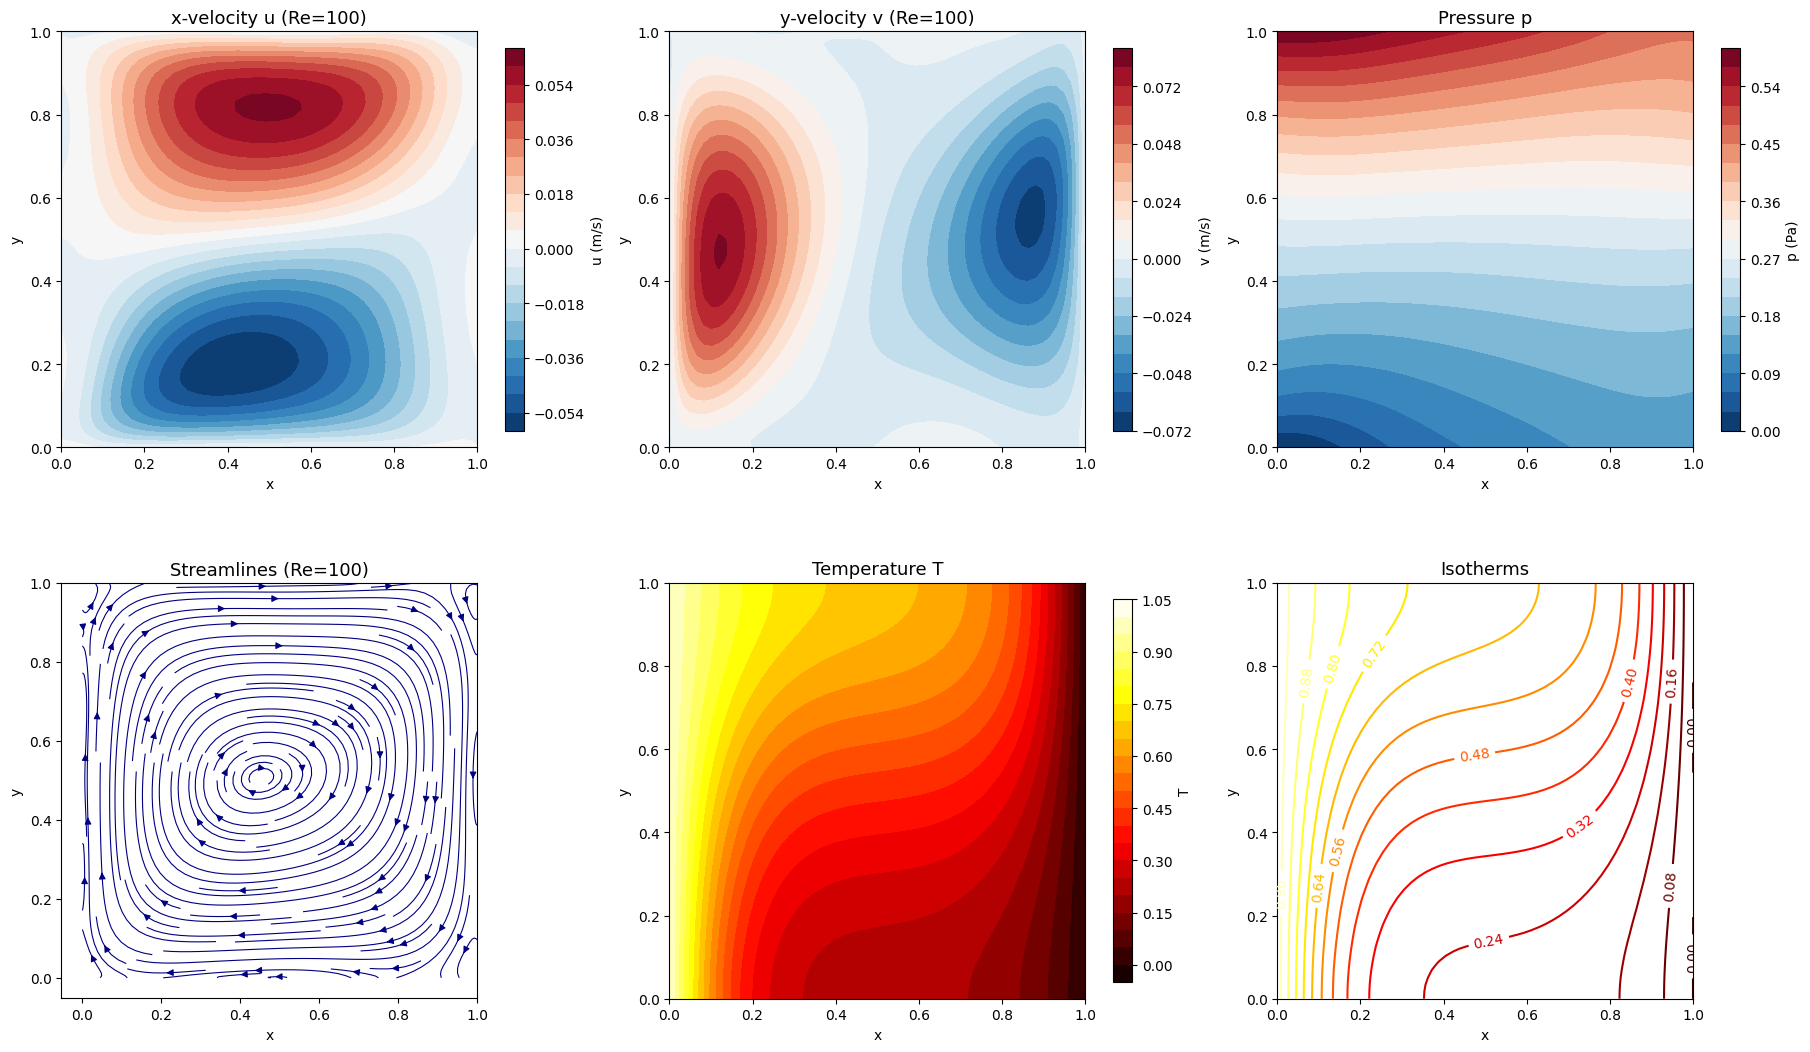

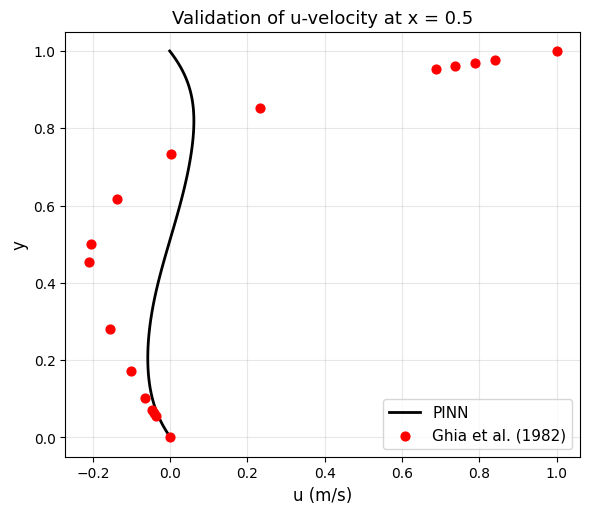

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)





# ============================================================
# Grille de calcul
# ============================================================
n = 60

xg = torch.linspace(0, 1, n, device=device)
yg = torch.linspace(0, 1, n, device=device)

XX, YY = torch.meshgrid(xg, yg, indexing="ij")

with torch.no_grad():
    out_g = pinn(
        torch.cat(
            [XX.reshape(-1, 1), YY.reshape(-1, 1)],
            dim=1
        )
    )

# ============================================================
# Extraction des variables
# ============================================================
U = out_g[:, 0].reshape(n, n).cpu().numpy()
V = out_g[:, 1].reshape(n, n).cpu().numpy()
P = out_g[:, 2].reshape(n, n).cpu().numpy()
T = out_g[:, 3].reshape(n, n).cpu().numpy()

XX_np = XX.cpu().numpy()
YY_np = YY.cpu().numpy()

# ============================================================
# ============================================================
# Figure 2 x 3 = 6 graphiques de même taille
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 11),
    constrained_layout=True
)

# ============================================================
# 1. x-velocity u
# ============================================================

c1 = axes[0, 0].contourf(
    XX_np, YY_np, U,
    levels=20,
    cmap="RdBu_r"
)

fig.colorbar(
    c1,
    ax=axes[0, 0],
    fraction=0.046,
    pad=0.04,
    label="u (m/s)"
)

axes[0, 0].set_title("x-velocity u (Re=100)", fontsize=13)
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].set_aspect("equal", adjustable="box")


# ============================================================
# 2. y-velocity v
# ============================================================

c2 = axes[0, 1].contourf(
    XX_np, YY_np, V,
    levels=20,
    cmap="RdBu_r"
)

fig.colorbar(
    c2,
    ax=axes[0, 1],
    fraction=0.046,
    pad=0.04,
    label="v (m/s)"
)

axes[0, 1].set_title("y-velocity v (Re=100)", fontsize=13)
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
axes[0, 1].set_aspect("equal", adjustable="box")


# ============================================================
# 3. Pressure p
# ============================================================

c3 = axes[0, 2].contourf(
    XX_np, YY_np, P,
    levels=20,
    cmap="RdBu_r"
)

fig.colorbar(
    c3,
    ax=axes[0, 2],
    fraction=0.046,
    pad=0.04,
    label="p (Pa)"
)

axes[0, 2].set_title("Pressure p", fontsize=13)
axes[0, 2].set_xlabel("x")
axes[0, 2].set_ylabel("y")
axes[0, 2].set_aspect("equal", adjustable="box")


# ============================================================
# 4. Streamlines
# ============================================================

axes[1, 0].streamplot(
    xg.cpu().numpy(),
    yg.cpu().numpy(),
    U.T,
    V.T,
    density=1.5,
    color="navy",
    linewidth=0.8
)

axes[1, 0].set_title("Streamlines (Re=100)", fontsize=13)
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
axes[1, 0].set_aspect("equal", adjustable="box")


# ============================================================
# 5. Temperature T
# ============================================================

c5 = axes[1, 1].contourf(
    XX_np, YY_np, T,
    levels=20,
    cmap="hot"
)

fig.colorbar(
    c5,
    ax=axes[1, 1],
    fraction=0.046,
    pad=0.04,
    label="T"
)

axes[1, 1].set_title("Temperature T", fontsize=13)
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
axes[1, 1].set_aspect("equal", adjustable="box")


# ============================================================
# 6. Isotherms
# ============================================================

c6 = axes[1, 2].contour(
    XX_np,
    YY_np,
    T,
    levels=15,
    cmap="hot"
)

axes[1, 2].clabel(
    c6,
    inline=True,
    fontsize=10,
    fmt="%.2f"
)

axes[1, 2].set_title("Isotherms", fontsize=13)
axes[1, 2].set_xlabel("x")
axes[1, 2].set_ylabel("y")
axes[1, 2].set_aspect("equal", adjustable="box")


# ============================================================
# Mise en page
# ============================================================

plt.show()


# ============================================================
# 7. VALIDATION - Ghia et al. (1982)
# ============================================================

ghia_y = np.array([
    0.0000, 0.0547, 0.0625, 0.0703,
    0.1016, 0.1719, 0.2813, 0.4531,
    0.5000, 0.6172, 0.7344, 0.8516,
    0.9531, 0.9609, 0.9688, 0.9766,
    1.0000
])

ghia_u = np.array([
    0.0000, -0.03717, -0.04192, -0.04775,
    -0.06434, -0.10150, -0.15663, -0.21090,
    -0.20581, -0.13641, 0.00332, 0.23151,
    0.68717, 0.73722, 0.78871, 0.84123,
    1.00000
])

# ------------------------------------------------------------
# PINN prediction along x = 0.5
# ------------------------------------------------------------

x_mid = torch.full(
    (100, 1),
    0.5,
    device=device
)

y_mid = torch.linspace(
    0, 1, 100,
    device=device
).view(-1, 1)

with torch.no_grad():
    u_mid = pinn(
        torch.cat([x_mid, y_mid], dim=1)
    )[:, 0].cpu().numpy()

# ------------------------------------------------------------
# Figure de validation
# ------------------------------------------------------------

fig_val, ax_val = plt.subplots(
    figsize=(6, 6)
)

ax_val.plot(
    u_mid,
    y_mid.cpu().numpy(),
    "k-",
    linewidth=2,
    label="PINN"
)

ax_val.scatter(
    ghia_u,
    ghia_y,
    color="red",
    s=40,
    zorder=5,
    label="Ghia et al. (1982)"
)

ax_val.set_xlabel(
    "u (m/s)",
    fontsize=12
)

ax_val.set_ylabel(
    "y",
    fontsize=12
)

ax_val.set_title(
    "Validation of u-velocity at x = 0.5",
    fontsize=13
)

ax_val.legend(
    fontsize=11
)

ax_val.grid(
    True,
    alpha=0.3
)

ax_val.set_aspect(
    "equal",
    adjustable="box"
)

plt.tight_layout()
plt.show()

---
## Section 5 — Analysis Questions

✏️ A1 — NS vs Stokes

**(a)** Compare your streamline plot (Re=10) to what you observed in WS4 (Stokes). Has the primary vortex centre shifted? In which direction, and why?

**(b)** From the centreline benchmark comparison: does your PINN broadly match the Ghia data? Where is the agreement best and where does it deviate?

**(c)** The training took 30,000 epochs. If the loss has not fully converged, what would you change first — the number of epochs, the learning rate, or the number of collocation points?

**Your answer (a):** *(double-click to edit)*

**Your answer (b):** *(double-click to edit)*

**Your answer (c):** *(double-click to edit)*

---
## Summary

<div style="background: #e8f4fd; border: 1.5px solid #2980b9; border-radius: 8px; padding: 16px 20px;">
🎓 <strong>Key Takeaways</strong>
<ol>
<li>The Navier-Stokes PINN differs from Stokes only by the <strong>nonlinear convection term</strong> $\rho(\mathbf{u}\cdot\nabla)\mathbf{u}$ in the momentum residuals.</li>
<li>This term is computed as a product of network outputs and their autograd derivatives — PyTorch handles the nonlinearity automatically.</li>
<li>At Re=100, the flow is qualitatively different from Stokes — inertia shifts the vortex and creates secondary structures at the corners.</li>
<li>The Ghia et al. benchmark provides a quantitative validation reference for the Re=10 lid-driven cavity.</li>
</ol>
</div>

*PINNs for Mechanical Engineers | CFD Series · Worksheet 5 · 2D Steady Navier-Stokes (Laminar)*